### Load data

In [1]:
import os
import sys
from glob import glob

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shared.utils as su
from utils.video import read_frames_decord

### MSRVTT

In [2]:
data_root = "/scratch/shared/beegfs/piyush/datasets/MSRVTT"
image_dir = f"{data_root}/videos/mid_frames/"
video_dir = f"{data_root}/videos/all/"

data = su.io.load_json(f"{data_root}/annotation/msrvtt_test_1k.json")
df = pd.DataFrame(data)

df['video_path'] = df.video.apply(lambda x: f"{video_dir}/{x}")
df['video_path'].apply(os.path.exists).mean()

df['image_path'] = df.video.apply(lambda x: f"{image_dir}/{x.replace('.mp4', '.png')}")
df['image_path'].apply(os.path.exists).mean()

text_col = "caption"

df.shape, df.iloc[0].to_dict()

((1000, 11),
 {'video_id': 'video7020',
  'video': 'video7020.mp4',
  'caption': 'a woman creating a fondant baby and flower',
  'source': 'MSR-VTT',
  'category': 10,
  'url': 'https://www.youtube.com/watch?v=4KRMJNBjrEs',
  'start time': 221.77,
  'end time': 233.08,
  'id': 7020,
  'video_path': '/scratch/shared/beegfs/piyush/datasets/MSRVTT/videos/all//video7020.mp4',
  'image_path': '/scratch/shared/beegfs/piyush/datasets/MSRVTT/videos/mid_frames//video7020.png'})

In [3]:
captions = df.caption.tolist()
image_paths = df.image_path.tolist()

In [21]:
import torch
import torch.nn.functional as F
import requests
from PIL import Image
from transformers import AutoTokenizer
from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration


model_path = "/work/piyush/pretrained_checkpoints/e5-v"
processor = LlavaNextProcessor.from_pretrained(model_path)
model = LlavaNextForConditionalGeneration.from_pretrained(
    model_path, torch_dtype=torch.bfloat16, device_map="auto", attn_implementation='flash_attention_2',
)

llama3_template = '<|start_header_id|>user<|end_header_id|>\n\n{}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n \n'

img_prompt = llama3_template.format('<image>\nSummary above image in one word: ')
text_prompt = llama3_template.format('<sent>\nSummary above sentence in one word: ')

# img_prompt = llama3_template.format('<image>')
# text_prompt = llama3_template.format('<sent>')

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [22]:
# urls = ['https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/American_Eskimo_Dog.jpg/360px-American_Eskimo_Dog.jpg',
#         'https://upload.wikimedia.org/wikipedia/commons/thumb/b/b6/Felis_catus-cat_on_snow.jpg/179px-Felis_catus-cat_on_snow.jpg']
# images = [Image.open(requests.get(url, stream=True).raw) for url in urls]

images = [Image.open("../../TimeBound.v1/sample_data/folding_paper-0.png"), Image.open("../../TimeBound.v1/sample_data/folding_paper-0.png")]

texts = ['A dog sitting in the grass.',
         'A cat standing in the snow.']

text_inputs = processor([text_prompt.replace('<sent>', text) for text in texts], return_tensors="pt", padding=True).to('cuda')
img_inputs = processor([img_prompt]*len(images), images, return_tensors="pt", padding=True).to('cuda')

with torch.no_grad():
    text_embs = model(**text_inputs, output_hidden_states=True, return_dict=True).hidden_states[-1][:, -1, :]
    img_embs = model(**img_inputs, output_hidden_states=True, return_dict=True).hidden_states[-1][:, -1, :]

    text_embs = F.normalize(text_embs, dim=-1)
    img_embs = F.normalize(img_embs, dim=-1)

print(text_embs @ img_embs.t())

tensor([[0.1553, 0.1553],
        [0.1543, 0.1543]], device='cuda:0', dtype=torch.bfloat16)


In [23]:
def embed_images(image_paths: list):
    images = [Image.open(f).convert("RGB") for f in image_paths]
    inputs = processor([img_prompt]*len(images), images, return_tensors="pt", padding=True).to('cuda')
    with torch.no_grad():
        embs = model(**inputs, output_hidden_states=True, return_dict=True).hidden_states[-1][:, -1, :]
        embs = F.normalize(embs, dim=-1).cpu().float()
    return embs


def embed_text(texts: list):
    inputs = processor([text_prompt.replace('<sent>', text) for text in texts], return_tensors="pt", padding=True).to('cuda')
    with torch.no_grad():
        embs = model(**inputs, output_hidden_states=True, return_dict=True).hidden_states[-1][:, -1, :]
        embs = F.normalize(embs, dim=-1).cpu().float()
    return embs

In [24]:
import numpy as np
from tqdm import tqdm

batch_size = 2
start_indices = np.arange(0, len(image_paths), batch_size)
embs_list = []
for si in tqdm(start_indices, desc="Embedding images"):
    image_batch = image_paths[si:si+batch_size]
    with torch.no_grad():
        embs = embed_images(image_batch)
    embs_list.append(embs)
embs_list = torch.cat(embs_list, dim=0)
embs_list.shape


start_indices = np.arange(0, len(captions), batch_size)
text_list = []
for si in tqdm(start_indices, desc="Embedding texts"):
    caps = captions[si:si+batch_size]
    with torch.no_grad():
        embs = embed_text(caps)
    text_list.append(embs)
text_list = torch.cat(text_list, dim=0)
text_list.shape

Embedding texts: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:40<00:00, 12.29it/s]


torch.Size([1000, 4096])

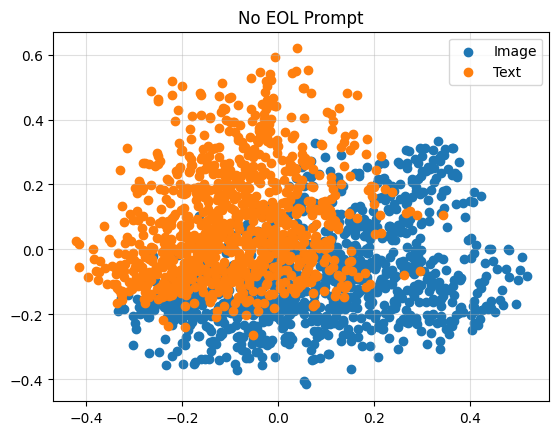

In [25]:
Z = torch.cat([embs_list, text_list])
z = su.visualize.reduce_dim(Z, method='pca')

plt.scatter(z[:len(image_paths), 0], z[:len(image_paths), 1], label='Image')
plt.scatter(z[len(image_paths):, 0], z[len(image_paths):, 1], label='Text')
plt.grid(alpha=0.4)
plt.legend()
plt.title("No EOL Prompt")
plt.show()

In [26]:
video_embeds = {
    p: v for p, v in zip(image_paths, embs_list)
}
texts_embeds = {p: v for p, v in zip(captions, text_list)}
len(video_embeds), len(texts_embeds)

(1000, 995)

In [27]:
X = []
Y = [] 
for i in range(len(df)):
    row = df.iloc[i].to_dict()
    zv = video_embeds[row['image_path']]
    zt = texts_embeds[row[text_col]]
    X.append(zv)
    Y.append(zt)
norm = lambda x: torch.nn.functional.normalize(x, dim=-1)
X = norm(torch.stack(X))
Y = norm(torch.stack(Y))
delta = np.round((X.mean(dim=0) - Y.mean(dim=0)).norm(dim=-1).item(), 2)
delta

0.31

In [28]:
vid2text = {}
for f in video_embeds:
    vid2text[f] = df[df.image_path == f].iloc[0][text_col]
len(vid2text)

1000

In [29]:
def visualize_modality_gap(_video_embeds: dict, _texts_embeds: dict, vid2text: dict, method='tsne', save_path=None, title='Modality Gap'):
    norm = lambda x: torch.nn.functional.normalize(x, dim=-1)
    ZV = torch.stack([_video_embeds[f] for f in _video_embeds])
    ZT = torch.stack([_texts_embeds[t] for t in _texts_embeds])
    Z = torch.concatenate([ZV, ZT], dim=0)
    Z = norm(Z)
    z = su.visualize.reduce_dim(Z, method=method)

    delta = np.round((norm(ZV).mean(dim=0) - norm(ZT).mean(dim=0)).norm(dim=-1).item(), 3)

    # Create mappings from video/text to their index in z
    video_list = list(_video_embeds.keys())
    text_list = list(_texts_embeds.keys())
    
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    
    # Draw matching lines first (so they appear behind the points)
    for i, f in enumerate(video_list):
        matched_text = vid2text[f]
        if matched_text in text_list:
            j = text_list.index(matched_text)
            # Draw line from video point to text point
            ax.plot([z[i, 0], z[len(ZV) + j, 0]], 
                    [z[i, 1], z[len(ZV) + j, 1]], 
                    color='lightgray', linewidth=0.5, alpha=0.5, zorder=1)
    
    # Draw scatter points on top
    ax.scatter(z[:len(ZV), 0], z[:len(ZV), 1], s=8, label='Video', zorder=2)
    ax.scatter(z[len(ZV):, 0], z[len(ZV):, 1], s=8, label='Text', zorder=2)
    
    ax.grid(alpha=0.3)
    ax.set_xlabel("$\\mathbf{z}_{1}$")
    ax.set_ylabel("$\\mathbf{z}_{2}$")
    ax.legend(fontsize=12)
    
    title += " (Delta = %s)" % np.round(delta, 3)
    print(title)
    ax.set_title(title, fontsize=14)

    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

With EOL Prompt (Delta = 0.311)


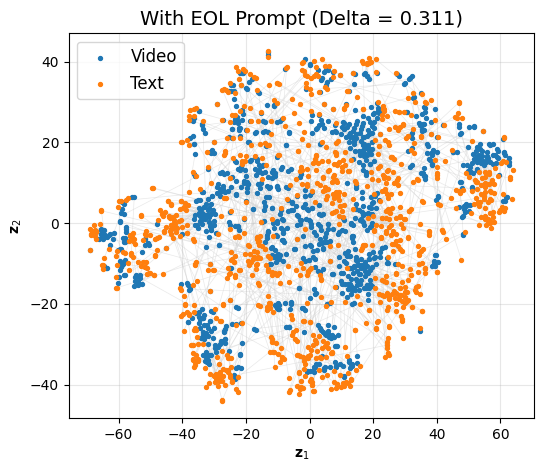

In [30]:
# save_path = '../figures/qwen3vlembedding8b-msrvtt-modgap.pdf'
# save_path = f'../figures/{model_key}-msrvtt-modgap.pdf'
# visualize_modality_gap(video_embeds, texts_embeds, vid2text, title="No EOL Prompt", method='tsne', save_path='../figures/llavanext-noeol.pdf')
visualize_modality_gap(video_embeds, texts_embeds, vid2text, title="With EOL Prompt", method='tsne', save_path='../figures/llavanext-eol.pdf')

In [1]:
import pandas as pd

df = pd.read_csv("./mscoco_t2i.csv")

# Sample 500 rows
df = df.sample(500)

df.shape

(500, 4)

In [2]:
captions = [i.split(": ")[1].strip("\n") for i in df['qry_text'].tolist()]
captions[:10]

['A herd of black sheep grazing near the shore.',
 'The girl is brushing her teeth and toothpaste and it is foaming up.',
 'Three different pots sit near one another on a table.',
 'A bathroom with a toilet, sink and mirror.',
 'A basketball player holds a basketball for a picture.',
 'The animal is standing by the booth at the event.',
 'There are three vases made of clay on a table.',
 'A pizza sliced in four slices on a plate.',
 'Reflections of light streaming thru a building window at night.',
 'A street sign above an orange detour sign.']

In [3]:
import numpy as np

data_dir = "/scratch/shared/beegfs/piyush/datasets/MMEB-V2/image-tasks/MMEB"
image_ids = eval(df['tgt_img_path'].iloc[0])
image_ids = np.random.choice(image_ids, size=500, replace=False)

image_paths =[f"{data_dir}/{x}" for x in image_ids]
image_paths[:4]

['/scratch/shared/beegfs/piyush/datasets/MMEB-V2/image-tasks/MMEB/MSCOCO_t2i/COCO_val2014_000000247184.jpg',
 '/scratch/shared/beegfs/piyush/datasets/MMEB-V2/image-tasks/MMEB/MSCOCO_t2i/COCO_val2014_000000556726.jpg',
 '/scratch/shared/beegfs/piyush/datasets/MMEB-V2/image-tasks/MMEB/MSCOCO_t2i/COCO_val2014_000000325211.jpg',
 '/scratch/shared/beegfs/piyush/datasets/MMEB-V2/image-tasks/MMEB/MSCOCO_t2i/COCO_val2014_000000362368.jpg']

In [1]:
import torch
import torch.nn.functional as F
import requests
from PIL import Image
from transformers import AutoTokenizer
from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration


In [2]:
model_path = "/work/piyush/pretrained_checkpoints/e5-v"
processor = LlavaNextProcessor.from_pretrained(model_path)
model = LlavaNextForConditionalGeneration.from_pretrained(model_path, torch_dtype=torch.bfloat16, device_map="auto", attn_implementation='flash_attention_2')

You are attempting to use Flash Attention 2.0 without specifying a torch dtype. This might lead to unexpected behaviour


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [17]:
llama3_template = '<|start_header_id|>user<|end_header_id|>\n\n{}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n \n'

# img_prompt = llama3_template.format('<image>\nSummary above image in one word: ')
# text_prompt = llama3_template.format('<sent>\nSummary above sentence in one word: ')

img_prompt = llama3_template.format('<image>')
text_prompt = llama3_template.format('<sent>')

# urls = ['https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/American_Eskimo_Dog.jpg/360px-American_Eskimo_Dog.jpg',
#         'https://upload.wikimedia.org/wikipedia/commons/thumb/b/b6/Felis_catus-cat_on_snow.jpg/179px-Felis_catus-cat_on_snow.jpg']
# images = [Image.open(requests.get(url, stream=True).raw) for url in urls]

# texts = ['A dog sitting in the grass.',
#          'A cat standing in the snow.']

# text_inputs = processor([text_prompt.replace('<sent>', text) for text in texts], return_tensors="pt", padding=True).to('cuda')
# img_inputs = processor([img_prompt]*len(images), images, return_tensors="pt", padding=True).to('cuda')

# with torch.no_grad():
#     text_embs = model(**text_inputs, output_hidden_states=True, return_dict=True).hidden_states[-1][:, -1, :]
#     img_embs = model(**img_inputs, output_hidden_states=True, return_dict=True).hidden_states[-1][:, -1, :]

#     text_embs = F.normalize(text_embs, dim=-1)
#     img_embs = F.normalize(img_embs, dim=-1)

# print(text_embs @ img_embs.t())

In [18]:
def embed_images(image_paths: list):
    images = [Image.open(f) for f in image_paths]
    inputs = processor([img_prompt]*len(images), images, return_tensors="pt", padding=True).to('cuda')
    with torch.no_grad():
        embs = model(**inputs, output_hidden_states=True, return_dict=True).hidden_states[-1][:, -1, :]
        embs = F.normalize(embs, dim=-1).cpu().float()
    return embs


def embed_text(texts: list):
    inputs = processor([text_prompt.replace('<sent>', text) for text in texts], return_tensors="pt", padding=True).to('cuda')
    with torch.no_grad():
        embs = model(**inputs, output_hidden_states=True, return_dict=True).hidden_states[-1][:, -1, :]
        embs = F.normalize(embs, dim=-1).cpu().float()
    return embs



In [19]:
embed_images(['../assets/logo.png']).shape, embed_text(['A dog sitting in the grass.']).shape

(torch.Size([1, 4096]), torch.Size([1, 4096]))

In [23]:
import numpy as np
from tqdm import tqdm

batch_size = 2
start_indices = np.arange(0, len(image_paths), batch_size)
embs_list = []
for si in tqdm(start_indices, desc="Embedding images"):
    image_batch = image_paths[si:si+batch_size]
    with torch.no_grad():
        embs = embed_images(image_batch)
    embs_list.append(embs)
embs_list = torch.cat(embs_list, dim=0)
embs_list.shape


Embedding images: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [05:17<00:00,  1.27s/it]


torch.Size([500, 4096])

In [24]:
start_indices = np.arange(0, len(captions), batch_size)
text_list = []
for si in tqdm(start_indices, desc="Embedding texts"):
    caps = captions[si:si+batch_size]
    with torch.no_grad():
        embs = embed_text(caps)
    text_list.append(embs)
text_list = torch.cat(text_list, dim=0)
text_list.shape

Embedding texts: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:19<00:00, 13.01it/s]


torch.Size([500, 4096])

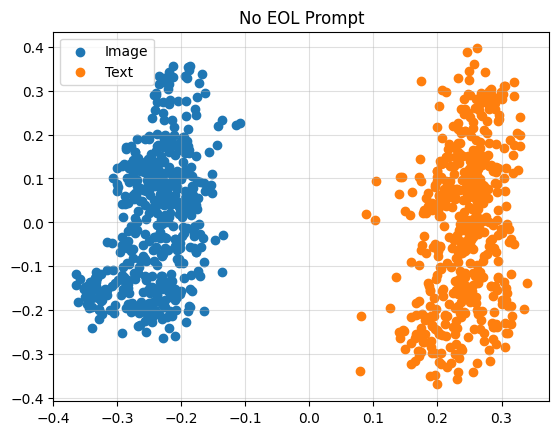

In [26]:
Z = torch.cat([embs_list, text_list])
z = su.visualize.reduce_dim(Z, method='pca')

plt.scatter(z[:len(image_paths), 0], z[:len(image_paths), 1], label='Image')
plt.scatter(z[len(image_paths):, 0], z[len(image_paths):, 1], label='Text')
plt.grid(alpha=0.4)
plt.legend()
plt.title("No EOL Prompt")
plt.show()

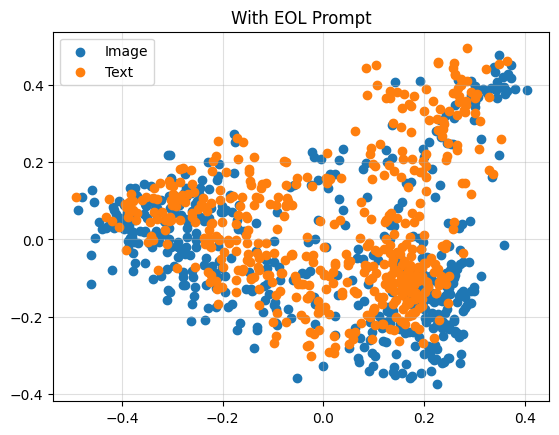

In [22]:
Z = torch.cat([embs_list, text_list])
z = su.visualize.reduce_dim(Z, method='pca')

plt.scatter(z[:len(image_paths), 0], z[:len(image_paths), 1], label='Image')
plt.scatter(z[len(image_paths):, 0], z[len(image_paths):, 1], label='Text')
plt.grid(alpha=0.4)
plt.legend()
plt.title("With EOL Prompt")
plt.show()

In [18]:
from models.modeling_encoders import AutoEncoder
import torch

model_path = "/work/piyush/pretrained_checkpoints/Qwen2-VL-7B-Instruct/"
model = AutoEncoder.from_pretrained(model_path, torch_dtype=torch.bfloat16, device_map="auto", attn_implementation='flash_attention_2')

Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}


Loading EncoderForQwen2VL from /work/piyush/pretrained_checkpoints/Qwen2-VL-7B-Instruct/


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

In [19]:
def read_image(image_path):
    import PIL
    image = PIL.Image.open(image_path)
    image = torch.tensor(np.asarray(image)).unsqueeze(0)
    image = image.permute((0, 3, 1, 2))
    return image


x = read_image("1.png")
print(x.shape)

z = model.encode_vision(x.unsqueeze(0), prompt="<video>").squeeze(0).cpu().float()
print(z.shape)

torch.Size([1, 3, 400, 400])
torch.Size([3584])


In [21]:
from tqdm import tqdm

embs_list = []
for i in tqdm(range(len(image_paths))):
    with torch.no_grad():
        z = model.encode_vision(read_image(image_paths[i]).unsqueeze(0), prompt='<video>').squeeze(0).cpu().float()
        embs_list.append(z)
embs_list = torch.stack(embs_list)
embs_list.shape

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [01:16<00:00,  6.51it/s]


torch.Size([500, 3584])

In [24]:
text_list = []
for i in tqdm(range(len(captions))):
    with torch.no_grad():
        z = model.encode_text(captions[i], prompt='<sent>').squeeze(0).cpu().float()
        text_list.append(z)
text_list = torch.stack(text_list)
text_list.shape

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:26<00:00, 19.15it/s]


torch.Size([500, 3584])

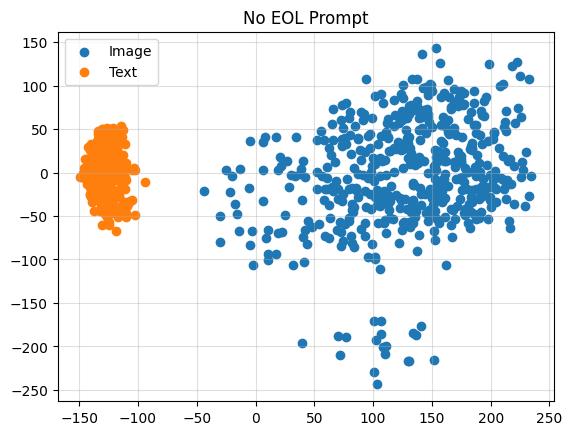

In [25]:
Z = torch.cat([embs_list, text_list])
z = su.visualize.reduce_dim(Z, method='pca')

plt.scatter(z[:len(image_paths), 0], z[:len(image_paths), 1], label='Image')
plt.scatter(z[len(image_paths):, 0], z[len(image_paths):, 1], label='Text')
plt.grid(alpha=0.4)
plt.legend()
plt.title("No EOL Prompt")
plt.show()